In [5]:
import gspread
from google.colab import auth
from google.auth import default
import pandas as pd

# Step 1: Authenticate Google Colab
auth.authenticate_user()

# Step 2: Authorize Google account
creds, _ = default()
gc = gspread.authorize(creds)

# Step 3: Paste your Google Sheet URL here
sheet_url = "https://docs.google.com/spreadsheets/d/1y_Ml1P-8wLzSeC2v_yZyMTUkzUleNxGrZtfxEuIuIi4/edit?usp=sharing"

# Step 4: Open the Google Sheet
spreadsheet = gc.open_by_url(sheet_url)

# Step 5: Select the first sheet/tab
worksheet = spreadsheet.sheet1

# Step 6: Read the data
data = worksheet.get_all_values()

# Step 7: Convert to Pandas DataFrame
df = pd.DataFrame(data[1:], columns=data[0])

# Step 8: Display the first 5 rows
df.head()

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 3900
Columns: 18


In [6]:
# 1. Create a clean copy
clean_df = df.copy()

# 2. Convert important columns to numbers
for col in ["Age", "Purchase Amount (USD)", "Review Rating", "Previous Purchases"]:
    clean_df[col] = pd.to_numeric(clean_df[col], errors="coerce")

# 3. Standardize purchase frequency
clean_df["Frequency of Purchases"] = clean_df["Frequency of Purchases"].replace({
    "Bi-Weekly": "Fortnightly",
    "Every 3 Months": "Quarterly"
})

# 4. Basic checks
print("Rows and Columns:", clean_df.shape)
print("Missing Values:", clean_df.isnull().sum().sum())
print("Duplicate Rows:", clean_df.duplicated().sum())

# 5. Show the cleaned data
clean_df.head()

Rows and Columns: (3900, 18)
Missing Values: 0
Duplicate Rows: 0


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [8]:
# Category analysis
category = clean_df.groupby("Category")["Purchase Amount (USD)"].agg(
    ["sum", "mean", "count"]
).sort_values("sum", ascending=False)

# Item analysis
items = clean_df.groupby("Item Purchased")["Purchase Amount (USD)"].sum().sort_values(ascending=False)

# Payment analysis
payment = clean_df["Payment Method"].value_counts()

# Subscription analysis
subscription = clean_df.groupby("Subscription Status")["Purchase Amount (USD)"].agg(
    ["sum", "mean", "count"]
)

# Discount analysis
discount = clean_df.groupby("Discount Applied")["Purchase Amount (USD)"].agg(
    ["sum", "mean", "count"]
)

# Overall KPIs
print("TOTAL PURCHASE: $", round(clean_df["Purchase Amount (USD)"].sum(), 2))
print("AVERAGE PURCHASE: $", round(clean_df["Purchase Amount (USD)"].mean(), 2))
print("AVERAGE RATING:", round(clean_df["Review Rating"].mean(), 2))
print("TOTAL CUSTOMERS:", clean_df["Customer ID"].nunique())

print("\nCATEGORY ANALYSIS")
print(category)

print("\nTOP 10 ITEMS")
print(items.head(10))

print("\nPAYMENT METHODS")
print(payment)

print("\nSUBSCRIPTION ANALYSIS")
print(subscription)

print("\nDISCOUNT ANALYSIS")
print(discount)

TOTAL PURCHASE: $ 233081
AVERAGE PURCHASE: $ 59.76
AVERAGE RATING: 3.75
TOTAL CUSTOMERS: 3900

CATEGORY ANALYSIS
                sum       mean  count
Category                             
Clothing     104264  60.025331   1737
Accessories   74200  59.838710   1240
Footwear      36093  60.255426    599
Outerwear     18524  57.172840    324

TOP 10 ITEMS
Item Purchased
Blouse        10410
Shirt         10332
Dress         10320
Pants         10090
Jewelry       10010
Sunglasses     9649
Belt           9635
Scarf          9561
Sweater        9462
Shorts         9433
Name: Purchase Amount (USD), dtype: int64

PAYMENT METHODS
Payment Method
PayPal           677
Credit Card      671
Cash             670
Debit Card       636
Venmo            634
Bank Transfer    612
Name: count, dtype: int64

SUBSCRIPTION ANALYSIS
                        sum       mean  count
Subscription Status                          
No                   170436  59.865121   2847
Yes                   62645  59.491928   10

In [9]:
# Age group analysis
clean_df["Age Group"] = pd.cut(
    clean_df["Age"],
    bins=[17, 25, 35, 45, 55, 70],
    labels=["18-25", "26-35", "36-45", "46-55", "56-70"]
)

age_group = clean_df.groupby("Age Group", observed=False)["Purchase Amount (USD)"].agg(
    ["sum", "mean", "count"]
)

# Gender analysis
gender = clean_df.groupby("Gender")["Purchase Amount (USD)"].agg(
    ["sum", "mean", "count"]
)

# Frequency analysis
frequency = clean_df["Frequency of Purchases"].value_counts()

print("AGE GROUP ANALYSIS")
print(age_group)

print("\nGENDER ANALYSIS")
print(gender)

print("\nPURCHASE FREQUENCY")
print(frequency)

AGE GROUP ANALYSIS
             sum       mean  count
Age Group                         
18-25      34630  60.647986    571
26-35      44342  59.760108    742
36-45      43234  59.305898    729
46-55      45619  60.583001    753
56-70      65256  59.055204   1105

GENDER ANALYSIS
           sum       mean  count
Gender                          
Female   75191  60.249199   1248
Male    157890  59.536199   2652

PURCHASE FREQUENCY
Frequency of Purchases
Quarterly      1147
Fortnightly    1089
Annually        572
Monthly         553
Weekly          539
Name: count, dtype: int64


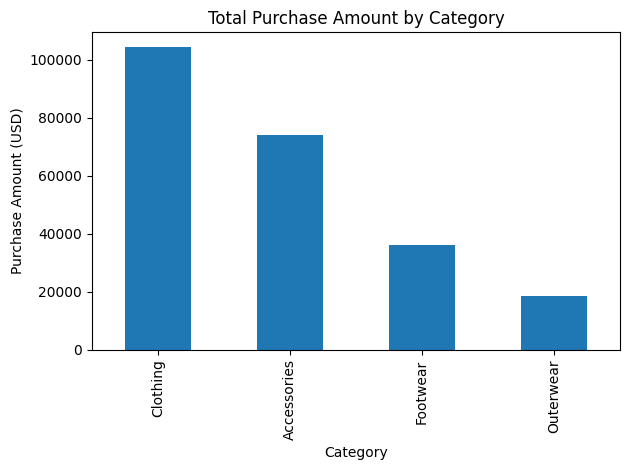

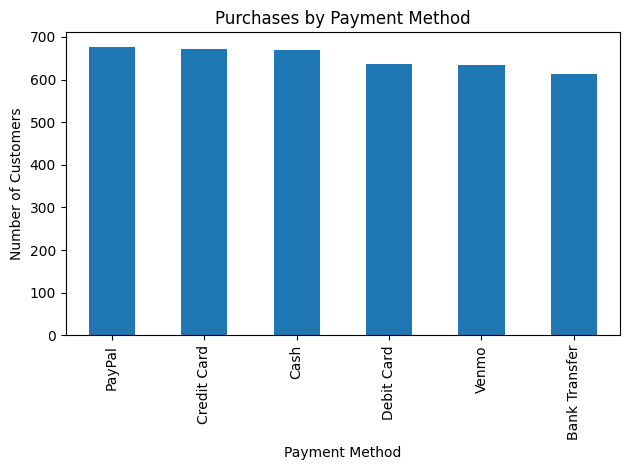

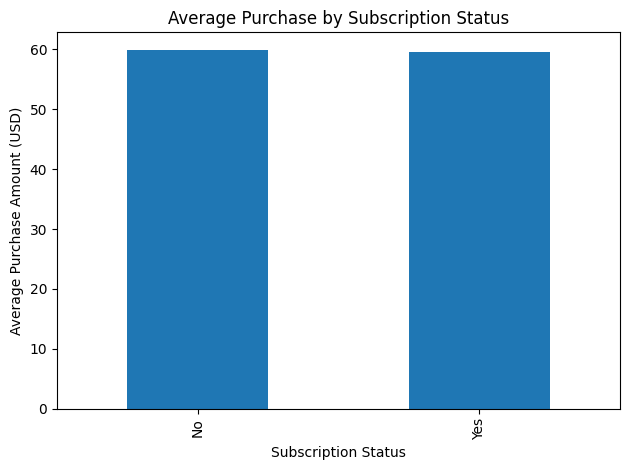

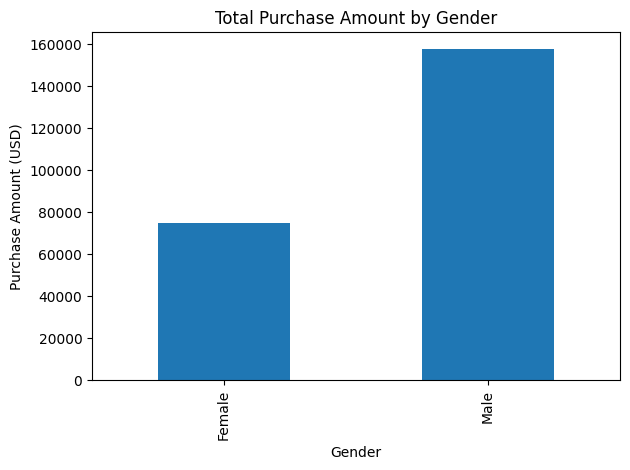

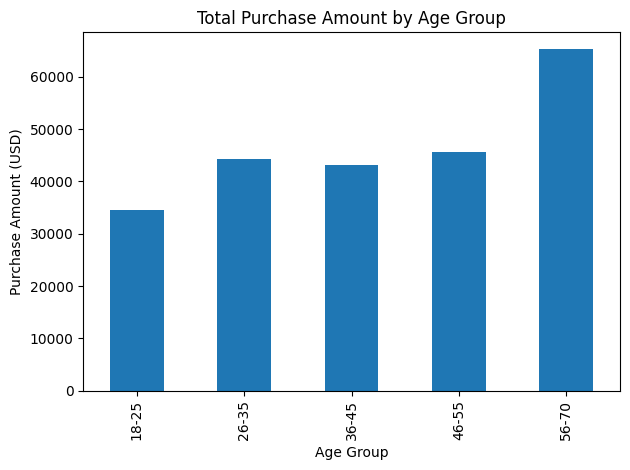

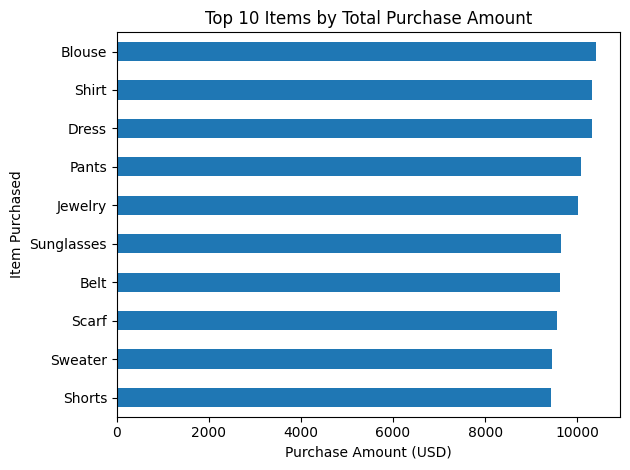

In [10]:
import matplotlib.pyplot as plt

# 1. Purchase by Category
category["sum"].plot(kind="bar", title="Total Purchase Amount by Category")
plt.ylabel("Purchase Amount (USD)")
plt.tight_layout()
plt.show()

# 2. Payment Methods
payment.plot(kind="bar", title="Purchases by Payment Method")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

# 3. Subscription Status
subscription["mean"].plot(kind="bar", title="Average Purchase by Subscription Status")
plt.ylabel("Average Purchase Amount (USD)")
plt.tight_layout()
plt.show()

# 4. Gender
gender["sum"].plot(kind="bar", title="Total Purchase Amount by Gender")
plt.ylabel("Purchase Amount (USD)")
plt.tight_layout()
plt.show()

# 5. Age Group
age_group["sum"].plot(kind="bar", title="Total Purchase Amount by Age Group")
plt.ylabel("Purchase Amount (USD)")
plt.tight_layout()
plt.show()

# 6. Top 10 Items
items.head(10).sort_values().plot(kind="barh", title="Top 10 Items by Total Purchase Amount")
plt.xlabel("Purchase Amount (USD)")
plt.tight_layout()
plt.show()

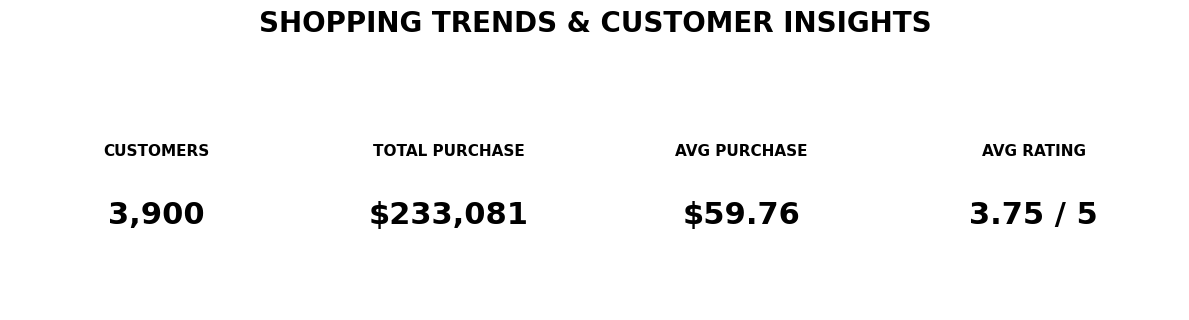

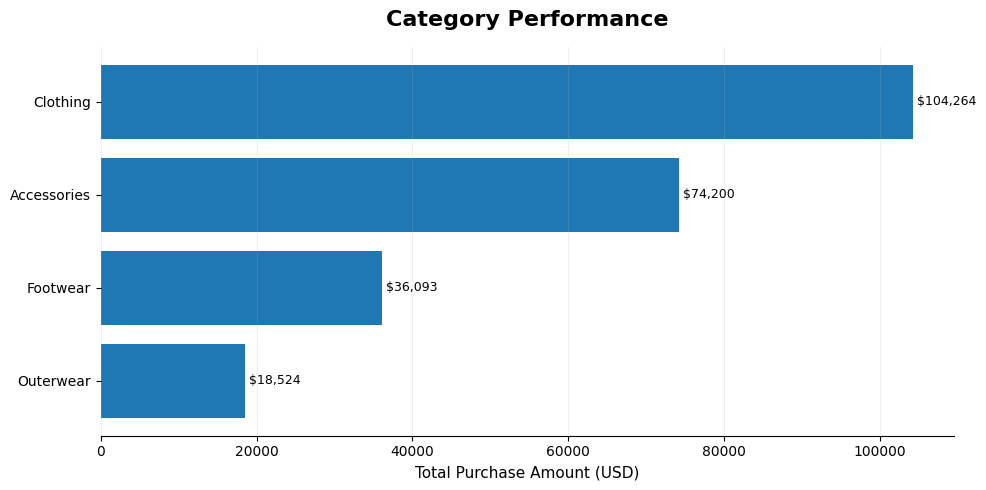

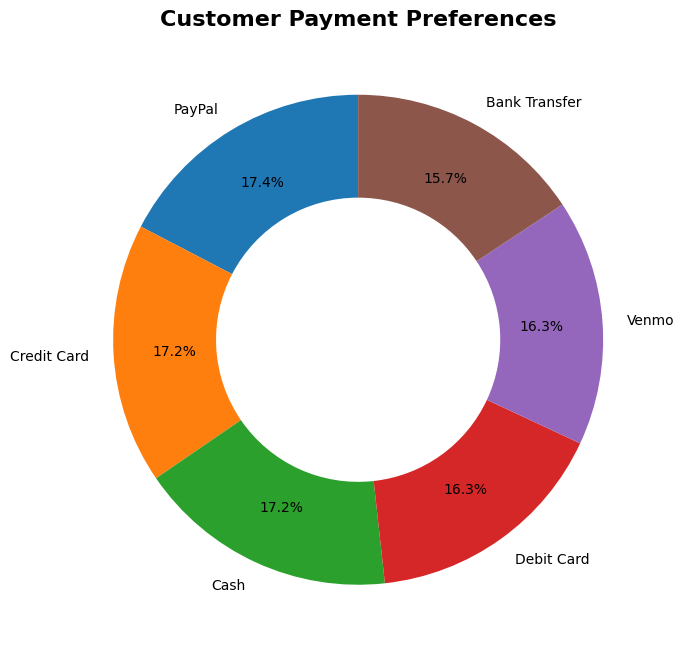

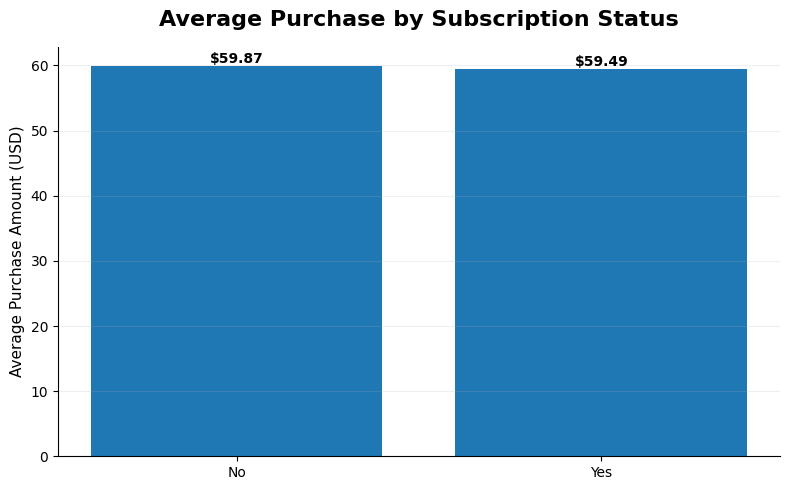

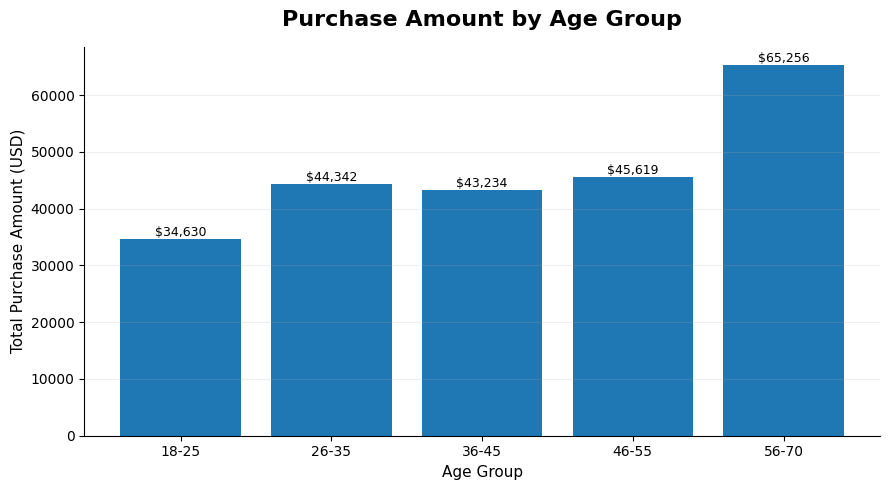

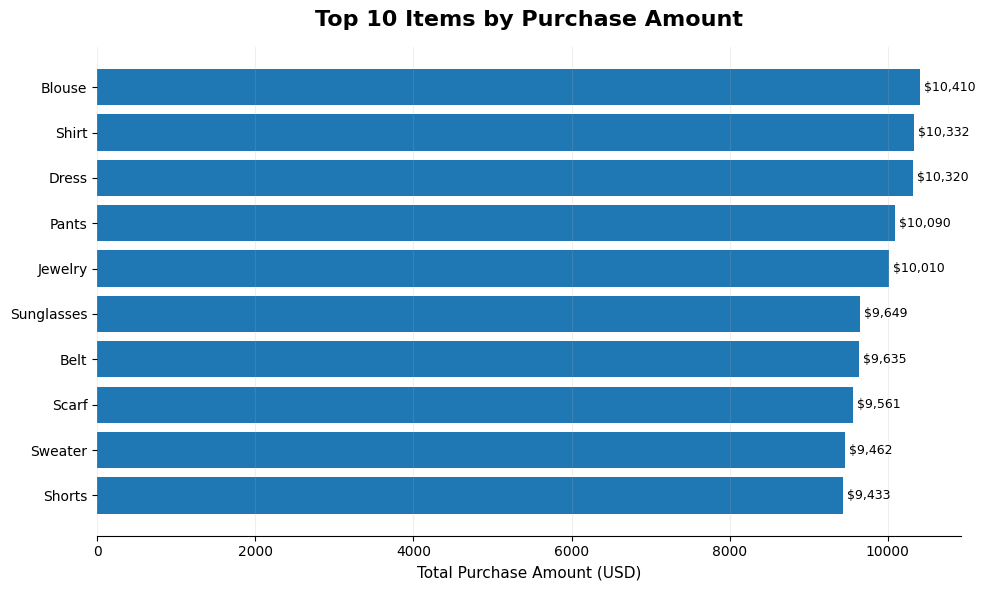

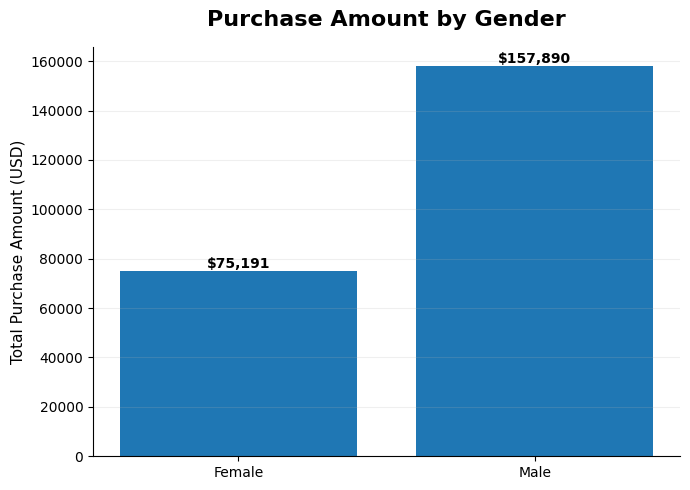

In [13]:
# ============================================================
# PROFESSIONAL SHOPPING TRENDS VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Professional style
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 11

# ------------------------------------------------------------
# 1. KPI SUMMARY
# ------------------------------------------------------------

total_customers = clean_df["Customer ID"].nunique()
total_sales = clean_df["Purchase Amount (USD)"].sum()
avg_purchase = clean_df["Purchase Amount (USD)"].mean()
avg_rating = clean_df["Review Rating"].mean()

fig, ax = plt.subplots(figsize=(12, 3))
ax.axis("off")

kpis = [
    ("CUSTOMERS", f"{total_customers:,}"),
    ("TOTAL PURCHASE", f"${total_sales:,.0f}"),
    ("AVG PURCHASE", f"${avg_purchase:.2f}"),
    ("AVG RATING", f"{avg_rating:.2f} / 5")
]

for i, (title, value) in enumerate(kpis):
    x = i * 0.25 + 0.125

    ax.text(
        x, 0.68, title,
        ha="center",
        fontsize=11,
        fontweight="bold",
        transform=ax.transAxes
    )

    ax.text(
        x, 0.38, value,
        ha="center",
        fontsize=22,
        fontweight="bold",
        transform=ax.transAxes
    )

plt.suptitle(
    "SHOPPING TRENDS & CUSTOMER INSIGHTS",
    fontsize=20,
    fontweight="bold",
    y=1.05
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. CATEGORY PERFORMANCE
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

data = category["sum"].sort_values()

bars = ax.barh(data.index, data.values)

ax.set_title("Category Performance", pad=15)
ax.set_xlabel("Total Purchase Amount (USD)")
ax.grid(axis="x", alpha=0.2)

for bar in bars:
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f" ${bar.get_width():,.0f}",
        va="center",
        fontsize=9
    )

ax.spines[["top", "right", "left"]].set_visible(False)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. PAYMENT METHOD
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 7))

wedges, texts, autotexts = ax.pie(
    payment.values,
    labels=payment.index,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.75,
    wedgeprops={"width": 0.42}
)

ax.set_title("Customer Payment Preferences", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. SUBSCRIPTION ANALYSIS
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))

data = subscription["mean"]

bars = ax.bar(data.index, data.values)

ax.set_title("Average Purchase by Subscription Status", pad=15)
ax.set_ylabel("Average Purchase Amount (USD)")
ax.grid(axis="y", alpha=0.2)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"${bar.get_height():.2f}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. AGE GROUP ANALYSIS
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 5))

data = age_group["sum"]

bars = ax.bar(data.index.astype(str), data.values)

ax.set_title("Purchase Amount by Age Group", pad=15)
ax.set_xlabel("Age Group")
ax.set_ylabel("Total Purchase Amount (USD)")
ax.grid(axis="y", alpha=0.2)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"${bar.get_height():,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. TOP 10 ITEMS
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

data = items.head(10).sort_values()

bars = ax.barh(data.index, data.values)

ax.set_title("Top 10 Items by Purchase Amount", pad=15)
ax.set_xlabel("Total Purchase Amount (USD)")
ax.grid(axis="x", alpha=0.2)

for bar in bars:
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f" ${bar.get_width():,.0f}",
        va="center",
        fontsize=9
    )

ax.spines[["top", "right", "left"]].set_visible(False)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. GENDER ANALYSIS
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 5))

data = gender["sum"]

bars = ax.bar(data.index, data.values)

ax.set_title("Purchase Amount by Gender", pad=15)
ax.set_ylabel("Total Purchase Amount (USD)")
ax.grid(axis="y", alpha=0.2)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"${bar.get_height():,.0f}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [14]:
import pandas as pd

# Create analysis tables
category_excel = category.reset_index()
category_excel.columns = ["Category", "Total Purchase", "Average Purchase", "Customer Count"]

payment_excel = payment.reset_index()
payment_excel.columns = ["Payment Method", "Customer Count"]

subscription_excel = subscription.reset_index()
subscription_excel.columns = ["Subscription Status", "Total Purchase", "Average Purchase", "Customer Count"]

gender_excel = gender.reset_index()
gender_excel.columns = ["Gender", "Total Purchase", "Average Purchase", "Customer Count"]

age_excel = age_group.reset_index()
age_excel.columns = ["Age Group", "Total Purchase", "Average Purchase", "Customer Count"]

items_excel = items.head(10).reset_index()
items_excel.columns = ["Item Purchased", "Total Purchase"]

frequency_excel = frequency.reset_index()
frequency_excel.columns = ["Purchase Frequency", "Customer Count"]

# Save everything into one Excel workbook
file_name = "Shopping_Trends_Analysis.xlsx"

with pd.ExcelWriter(file_name, engine="openpyxl") as writer:
    clean_df.to_excel(writer, sheet_name="Clean Data", index=False)
    category_excel.to_excel(writer, sheet_name="Category Analysis", index=False)
    payment_excel.to_excel(writer, sheet_name="Payment Analysis", index=False)
    subscription_excel.to_excel(writer, sheet_name="Subscription", index=False)
    gender_excel.to_excel(writer, sheet_name="Gender Analysis", index=False)
    age_excel.to_excel(writer, sheet_name="Age Analysis", index=False)
    items_excel.to_excel(writer, sheet_name="Top Items", index=False)
    frequency_excel.to_excel(writer, sheet_name="Purchase Frequency", index=False)

print("Excel workbook created successfully!")
print(file_name)

Excel workbook created successfully!
Shopping_Trends_Analysis.xlsx


In [15]:
# ============================================================
# CREATE PROFESSIONAL EXCEL DASHBOARD
# ============================================================

from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.chart import BarChart, DoughnutChart, Reference
from openpyxl.chart.label import DataLabelList

file_name = "Shopping_Trends_Analysis.xlsx"

# Open workbook
wb = load_workbook(file_name)

# Remove old Dashboard if it exists
if "Dashboard" in wb.sheetnames:
    del wb["Dashboard"]

# Create Dashboard as the first sheet
ws = wb.create_sheet("Dashboard", 0)

# ------------------------------------------------------------
# TITLE
# ------------------------------------------------------------

ws.merge_cells("A1:L2")
ws["A1"] = "SHOPPING TRENDS & CUSTOMER INSIGHTS"
ws["A1"].font = Font(size=22, bold=True)
ws["A1"].alignment = Alignment(horizontal="center", vertical="center")

ws.merge_cells("A3:L3")
ws["A3"] = "Customer Purchase Analysis Dashboard"
ws["A3"].font = Font(size=12, italic=True)
ws["A3"].alignment = Alignment(horizontal="center")

# ------------------------------------------------------------
# KPI VALUES
# ------------------------------------------------------------

total_customers = clean_df["Customer ID"].nunique()
total_sales = clean_df["Purchase Amount (USD)"].sum()
avg_purchase = clean_df["Purchase Amount (USD)"].mean()
avg_rating = clean_df["Review Rating"].mean()

kpis = [
    ("A5:C5", "A6:C8", "TOTAL CUSTOMERS", f"{total_customers:,}"),
    ("D5:F5", "D6:F8", "TOTAL PURCHASE", f"${total_sales:,.2f}"),
    ("G5:I5", "G6:I8", "AVG PURCHASE", f"${avg_purchase:.2f}"),
    ("J5:L5", "J6:L8", "AVG RATING", f"{avg_rating:.2f} / 5")
]

for title_range, value_range, title, value in kpis:

    ws.merge_cells(title_range)
    ws.merge_cells(value_range)

    title_cell = ws[title_range.split(":")[0]]
    value_cell = ws[value_range.split(":")[0]]

    title_cell.value = title
    value_cell.value = value

    title_cell.font = Font(size=11, bold=True)
    title_cell.alignment = Alignment(horizontal="center", vertical="center")

    value_cell.font = Font(size=20, bold=True)
    value_cell.alignment = Alignment(horizontal="center", vertical="center")

# ------------------------------------------------------------
# SECTION HEADINGS
# ------------------------------------------------------------

ws.merge_cells("A10:F10")
ws["A10"] = "CATEGORY PERFORMANCE"
ws["A10"].font = Font(size=14, bold=True)
ws["A10"].alignment = Alignment(horizontal="center")

ws.merge_cells("G10:L10")
ws["G10"] = "PAYMENT PREFERENCES"
ws["G10"].font = Font(size=14, bold=True)
ws["G10"].alignment = Alignment(horizontal="center")

ws.merge_cells("A27:F27")
ws["A27"] = "AGE GROUP PURCHASES"
ws["A27"].font = Font(size=14, bold=True)
ws["A27"].alignment = Alignment(horizontal="center")

ws.merge_cells("G27:L27")
ws["G27"] = "SUBSCRIPTION ANALYSIS"
ws["G27"].font = Font(size=14, bold=True)
ws["G27"].alignment = Alignment(horizontal="center")

# ------------------------------------------------------------
# CATEGORY BAR CHART
# ------------------------------------------------------------

cat_ws = wb["Category Analysis"]

chart1 = BarChart()
chart1.type = "bar"
chart1.style = 10
chart1.title = "Total Purchase by Category"
chart1.y_axis.title = "Category"
chart1.x_axis.title = "Purchase Amount"

data = Reference(cat_ws, min_col=2, min_row=1, max_row=cat_ws.max_row)
cats = Reference(cat_ws, min_col=1, min_row=2, max_row=cat_ws.max_row)

chart1.add_data(data, titles_from_data=True)
chart1.set_categories(cats)
chart1.height = 7
chart1.width = 12

chart1.dataLabels = DataLabelList()
chart1.dataLabels.showVal = True

ws.add_chart(chart1, "A11")

# ------------------------------------------------------------
# PAYMENT DOUGHNUT CHART
# ------------------------------------------------------------

pay_ws = wb["Payment Analysis"]

chart2 = DoughnutChart()
chart2.title = "Payment Method Distribution"

data = Reference(pay_ws, min_col=2, min_row=1, max_row=pay_ws.max_row)
labels = Reference(pay_ws, min_col=1, min_row=2, max_row=pay_ws.max_row)

chart2.add_data(data, titles_from_data=True)
chart2.set_categories(labels)
chart2.height = 7
chart2.width = 12

ws.add_chart(chart2, "G11")

# ------------------------------------------------------------
# AGE GROUP CHART
# ------------------------------------------------------------

age_ws = wb["Age Analysis"]

chart3 = BarChart()
chart3.type = "col"
chart3.style = 10
chart3.title = "Purchase Amount by Age Group"
chart3.y_axis.title = "Purchase Amount"
chart3.x_axis.title = "Age Group"

data = Reference(age_ws, min_col=2, min_row=1, max_row=age_ws.max_row)
cats = Reference(age_ws, min_col=1, min_row=2, max_row=age_ws.max_row)

chart3.add_data(data, titles_from_data=True)
chart3.set_categories(cats)
chart3.height = 7
chart3.width = 12

chart3.dataLabels = DataLabelList()
chart3.dataLabels.showVal = True

ws.add_chart(chart3, "A28")

# ------------------------------------------------------------
# SUBSCRIPTION CHART
# ------------------------------------------------------------

sub_ws = wb["Subscription"]

chart4 = BarChart()
chart4.type = "col"
chart4.style = 10
chart4.title = "Average Purchase by Subscription Status"
chart4.y_axis.title = "Average Purchase"
chart4.x_axis.title = "Subscription Status"

data = Reference(sub_ws, min_col=3, min_row=1, max_row=sub_ws.max_row)
cats = Reference(sub_ws, min_col=1, min_row=2, max_row=sub_ws.max_row)

chart4.add_data(data, titles_from_data=True)
chart4.set_categories(cats)
chart4.height = 7
chart4.width = 12

chart4.dataLabels = DataLabelList()
chart4.dataLabels.showVal = True

ws.add_chart(chart4, "G28")

# ------------------------------------------------------------
# FORMATTING
# ------------------------------------------------------------

# Column widths
for col in range(1, 13):
    ws.column_dimensions[chr(64 + col)].width = 14

# Row heights
ws.row_dimensions[1].height = 30
ws.row_dimensions[2].height = 30
ws.row_dimensions[3].height = 22

# Hide gridlines
ws.sheet_view.showGridLines = False

# Freeze panes
ws.freeze_panes = "A5"

# Save workbook
wb.save(file_name)

print("Dashboard created successfully!")
print("File:", file_name)

Dashboard created successfully!
File: Shopping_Trends_Analysis.xlsx


In [16]:
from google.colab import files

files.download("Shopping_Trends_Analysis.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
from openpyxl import load_workbook
from openpyxl.styles import Font, Alignment, PatternFill, Border, Side
from openpyxl.chart import BarChart, DoughnutChart, Reference
from openpyxl.chart.label import DataLabelList

file_name = "Shopping_Trends_Analysis.xlsx"

wb = load_workbook(file_name)

# Remove old dashboard
if "Dashboard" in wb.sheetnames:
    del wb["Dashboard"]

# Create fresh dashboard
ws = wb.create_sheet("Dashboard", 0)

# ============================================================
# PAGE SETTINGS
# ============================================================

ws.sheet_view.showGridLines = False
ws.freeze_panes = "A5"

for col in range(1, 13):
    ws.column_dimensions[chr(64 + col)].width = 12

for row in range(1, 45):
    ws.row_dimensions[row].height = 22

# ============================================================
# TITLE
# ============================================================

ws.merge_cells("A1:L2")
ws["A1"] = "SHOPPING TRENDS & CUSTOMER INSIGHTS"
ws["A1"].font = Font(size=22, bold=True)
ws["A1"].alignment = Alignment(horizontal="center", vertical="center")

ws.merge_cells("A3:L3")
ws["A3"] = "Customer Purchase Analysis Dashboard"
ws["A3"].font = Font(size=11, italic=True)
ws["A3"].alignment = Alignment(horizontal="center")

# ============================================================
# KPI CARDS
# ============================================================

total_customers = clean_df["Customer ID"].nunique()
total_sales = clean_df["Purchase Amount (USD)"].sum()
avg_purchase = clean_df["Purchase Amount (USD)"].mean()
avg_rating = clean_df["Review Rating"].mean()

kpis = [
    ("A5:C5", "A6:C8", "TOTAL CUSTOMERS", f"{total_customers:,}"),
    ("D5:F5", "D6:F8", "TOTAL PURCHASE", f"${total_sales:,.2f}"),
    ("G5:I5", "G6:I8", "AVG PURCHASE", f"${avg_purchase:.2f}"),
    ("J5:L5", "J6:L8", "AVG RATING", f"{avg_rating:.2f} / 5")
]

thin_border = Border(
    left=Side(style="thin"),
    right=Side(style="thin"),
    top=Side(style="thin"),
    bottom=Side(style="thin")
)

for title_range, value_range, title, value in kpis:

    ws.merge_cells(title_range)
    ws.merge_cells(value_range)

    title_cell = ws[title_range.split(":")[0]]
    value_cell = ws[value_range.split(":")[0]]

    title_cell.value = title
    value_cell.value = value

    title_cell.font = Font(size=10, bold=True)
    title_cell.alignment = Alignment(horizontal="center", vertical="center")

    value_cell.font = Font(size=20, bold=True)
    value_cell.alignment = Alignment(horizontal="center", vertical="center")

    # Border around card
    start = title_range.split(":")[0]
    end = title_range.split(":")[1]

    for row in ws[start:end][0]:
        row.border = thin_border

# ============================================================
# SECTION TITLES
# ============================================================

sections = {
    "A10:F10": "CATEGORY PERFORMANCE",
    "G10:L10": "PAYMENT PREFERENCES",
    "A28:F28": "AGE GROUP PURCHASES",
    "G28:L28": "SUBSCRIPTION ANALYSIS"
}

for cell_range, text in sections.items():
    ws.merge_cells(cell_range)
    cell = ws[cell_range.split(":")[0]]
    cell.value = text
    cell.font = Font(size=13, bold=True)
    cell.alignment = Alignment(horizontal="center", vertical="center")

# ============================================================
# CATEGORY CHART
# ============================================================

cat_ws = wb["Category Analysis"]

chart1 = BarChart()
chart1.type = "bar"
chart1.style = 10
chart1.title = "Purchase Amount by Category"
chart1.y_axis.title = ""
chart1.x_axis.title = "Purchase Amount"

data = Reference(cat_ws, min_col=2, min_row=1, max_row=cat_ws.max_row)
cats = Reference(cat_ws, min_col=1, min_row=2, max_row=cat_ws.max_row)

chart1.add_data(data, titles_from_data=True)
chart1.set_categories(cats)

chart1.height = 7
chart1.width = 11

chart1.legend = None

ws.add_chart(chart1, "A11")

# ============================================================
# PAYMENT CHART
# ============================================================

pay_ws = wb["Payment Analysis"]

chart2 = DoughnutChart()
chart2.title = "Payment Method Distribution"

data = Reference(pay_ws, min_col=2, min_row=1, max_row=pay_ws.max_row)
labels = Reference(pay_ws, min_col=1, min_row=2, max_row=pay_ws.max_row)

chart2.add_data(data, titles_from_data=True)
chart2.set_categories(labels)

chart2.height = 7
chart2.width = 11

ws.add_chart(chart2, "G11")

# ============================================================
# AGE GROUP CHART
# ============================================================

age_ws = wb["Age Analysis"]

chart3 = BarChart()
chart3.type = "col"
chart3.style = 10
chart3.title = "Purchase Amount by Age Group"
chart3.y_axis.title = "Purchase Amount"
chart3.x_axis.title = "Age Group"

data = Reference(age_ws, min_col=2, min_row=1, max_row=age_ws.max_row)
cats = Reference(age_ws, min_col=1, min_row=2, max_row=age_ws.max_row)

chart3.add_data(data, titles_from_data=True)
chart3.set_categories(cats)

chart3.height = 7
chart3.width = 11

chart3.legend = None

ws.add_chart(chart3, "A29")

# ============================================================
# SUBSCRIPTION CHART
# ============================================================

sub_ws = wb["Subscription"]

chart4 = BarChart()
chart4.type = "col"
chart4.style = 10
chart4.title = "Average Purchase by Subscription"
chart4.y_axis.title = "Average Purchase"
chart4.x_axis.title = "Subscription"

data = Reference(sub_ws, min_col=3, min_row=1, max_row=sub_ws.max_row)
cats = Reference(sub_ws, min_col=1, min_row=2, max_row=sub_ws.max_row)

chart4.add_data(data, titles_from_data=True)
chart4.set_categories(cats)

chart4.height = 7
chart4.width = 11

chart4.legend = None

ws.add_chart(chart4, "G29")

# ============================================================
# PRINT / VIEW SETTINGS
# ============================================================

ws.sheet_properties.pageSetUpPr.fitToPage = True
ws.page_setup.fitToWidth = 1
ws.page_setup.fitToHeight = 1
ws.page_setup.orientation = "landscape"

# Save
wb.save(file_name)

print("Clean dashboard created successfully!")

Clean dashboard created successfully!


In [18]:
from google.colab import files
files.download("Shopping_Trends_Analysis.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
from openpyxl import load_workbook
from openpyxl.chart import BarChart, DoughnutChart, Reference
from openpyxl.chart.label import DataLabelList

file_name = "Shopping_Trends_Analysis.xlsx"

wb = load_workbook(file_name)

# Remove existing dashboard
if "Dashboard" in wb.sheetnames:
    del wb["Dashboard"]

ws = wb.create_sheet("Dashboard", 0)

# ------------------------------------------------------------
# BASIC LAYOUT
# ------------------------------------------------------------

ws.sheet_view.showGridLines = False

for col in range(1, 13):
    ws.column_dimensions[chr(64 + col)].width = 12

for row in range(1, 50):
    ws.row_dimensions[row].height = 22

# ------------------------------------------------------------
# TITLE
# ------------------------------------------------------------

ws.merge_cells("A1:L2")
ws["A1"] = "SHOPPING TRENDS & CUSTOMER INSIGHTS"
ws["A1"].font = Font(size=22, bold=True)
ws["A1"].alignment = Alignment(horizontal="center", vertical="center")

ws.merge_cells("A3:L3")
ws["A3"] = "Customer Purchase Analysis Dashboard"
ws["A3"].font = Font(size=11, italic=True)
ws["A3"].alignment = Alignment(horizontal="center")

# ------------------------------------------------------------
# KPI CARDS
# ------------------------------------------------------------

total_customers = clean_df["Customer ID"].nunique()
total_sales = clean_df["Purchase Amount (USD)"].sum()
avg_purchase = clean_df["Purchase Amount (USD)"].mean()
avg_rating = clean_df["Review Rating"].mean()

kpis = [
    ("A5:C5", "A6:C8", "TOTAL CUSTOMERS", f"{total_customers:,}"),
    ("D5:F5", "D6:F8", "TOTAL PURCHASE", f"${total_sales:,.2f}"),
    ("G5:I5", "G6:I8", "AVG PURCHASE", f"${avg_purchase:.2f}"),
    ("J5:L5", "J6:L8", "AVG RATING", f"{avg_rating:.2f} / 5")
]

for title_range, value_range, title, value in kpis:

    ws.merge_cells(title_range)
    ws.merge_cells(value_range)

    title_cell = ws[title_range.split(":")[0]]
    value_cell = ws[value_range.split(":")[0]]

    title_cell.value = title
    value_cell.value = value

    title_cell.font = Font(size=10, bold=True)
    title_cell.alignment = Alignment(horizontal="center", vertical="center")

    value_cell.font = Font(size=20, bold=True)
    value_cell.alignment = Alignment(horizontal="center", vertical="center")

# ------------------------------------------------------------
# SECTION TITLES
# ------------------------------------------------------------

sections = {
    "A10:F10": "CATEGORY PERFORMANCE",
    "G10:L10": "PAYMENT PREFERENCES",
    "A28:F28": "AGE GROUP PURCHASES",
    "G28:L28": "SUBSCRIPTION ANALYSIS"
}

for cell_range, text in sections.items():
    ws.merge_cells(cell_range)
    cell = ws[cell_range.split(":")[0]]
    cell.value = text
    cell.font = Font(size=13, bold=True)
    cell.alignment = Alignment(horizontal="center", vertical="center")

# ------------------------------------------------------------
# 1. CATEGORY CHART WITH VALUES
# ------------------------------------------------------------

cat_ws = wb["Category Analysis"]

chart1 = BarChart()
chart1.type = "bar"
chart1.style = 10
chart1.title = "Purchase Amount by Category"
chart1.x_axis.title = "Purchase Amount"
chart1.y_axis.title = ""

data = Reference(
    cat_ws,
    min_col=2,
    min_row=1,
    max_row=cat_ws.max_row
)

cats = Reference(
    cat_ws,
    min_col=1,
    min_row=2,
    max_row=cat_ws.max_row
)

chart1.add_data(data, titles_from_data=True)
chart1.set_categories(cats)

chart1.height = 7
chart1.width = 11
chart1.legend = None

# SHOW VALUE ON EVERY BAR
chart1.dataLabels = DataLabelList()
chart1.dataLabels.showVal = True

ws.add_chart(chart1, "A11")

# ------------------------------------------------------------
# 2. PAYMENT CHART
# ------------------------------------------------------------

pay_ws = wb["Payment Analysis"]

chart2 = DoughnutChart()
chart2.title = "Payment Method Distribution"

data = Reference(
    pay_ws,
    min_col=2,
    min_row=1,
    max_row=pay_ws.max_row
)

labels = Reference(
    pay_ws,
    min_col=1,
    min_row=2,
    max_row=pay_ws.max_row
)

chart2.add_data(data, titles_from_data=True)
chart2.set_categories(labels)

chart2.height = 7
chart2.width = 11


ws.add_chart(chart2, "G11")

# ------------------------------------------------------------
# 3. AGE GROUP CHART WITH VALUES
# ------------------------------------------------------------

age_ws = wb["Age Analysis"]

chart3 = BarChart()
chart3.type = "col"
chart3.style = 10
chart3.title = "Purchase Amount by Age Group"
chart3.y_axis.title = "Purchase Amount"
chart3.x_axis.title = "Age Group"

data = Reference(
    age_ws,
    min_col=2,
    min_row=1,
    max_row=age_ws.max_row
)

cats = Reference(
    age_ws,
    min_col=1,
    min_row=2,
    max_row=age_ws.max_row
)

chart3.add_data(data, titles_from_data=True)
chart3.set_categories(cats)

chart3.height = 7
chart3.width = 11
chart3.legend = None

# SHOW VALUE ON EVERY BAR
chart3.dataLabels = DataLabelList()
chart3.dataLabels.showVal = True

ws.add_chart(chart3, "A29")

# ------------------------------------------------------------
# 4. SUBSCRIPTION CHART WITH VALUES
# ------------------------------------------------------------

sub_ws = wb["Subscription"]

chart4 = BarChart()
chart4.type = "col"
chart4.style = 10
chart4.title = "Average Purchase by Subscription"
chart4.y_axis.title = "Average Purchase"
chart4.x_axis.title = "Subscription"

data = Reference(
    sub_ws,
    min_col=3,
    min_row=1,
    max_row=sub_ws.max_row
)

cats = Reference(
    sub_ws,
    min_col=1,
    min_row=2,
    max_row=sub_ws.max_row
)

chart4.add_data(data, titles_from_data=True)
chart4.set_categories(cats)

chart4.height = 7
chart4.width = 11
chart4.legend = None

# SHOW VALUE ON EVERY BAR
chart4.dataLabels = DataLabelList()
chart4.dataLabels.showVal = True

ws.add_chart(chart4, "G29")

# ------------------------------------------------------------
# PAGE SETTINGS
# ------------------------------------------------------------

ws.sheet_properties.pageSetUpPr.fitToPage = True
ws.page_setup.fitToWidth = 1
ws.page_setup.fitToHeight = 1
ws.page_setup.orientation = "landscape"

wb.save(file_name)

print("Dashboard updated with values on every bar!")

Dashboard updated with values on every bar!


In [22]:
from google.colab import files
files.download("Shopping_Trends_Analysis.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
print("=" * 60)
print("FINAL PROJECT RESULTS")
print("=" * 60)

print("\n1. OVERALL")
print("Total Customers:", clean_df["Customer ID"].nunique())
print("Total Purchase Amount: $", round(clean_df["Purchase Amount (USD)"].sum(), 2))
print("Average Purchase Amount: $", round(clean_df["Purchase Amount (USD)"].mean(), 2))
print("Average Review Rating:", round(clean_df["Review Rating"].mean(), 2))

print("\n2. CATEGORY")
print(category)

print("\n3. TOP 10 ITEMS")
print(items.head(10))

print("\n4. PAYMENT METHODS")
print(payment)

print("\n5. SUBSCRIPTION")
print(subscription)

print("\n6. DISCOUNT")
print(discount)

print("\n7. AGE GROUP")
print(age_group)

print("\n8. GENDER")
print(gender)

print("\n9. PURCHASE FREQUENCY")
print(frequency)

FINAL PROJECT RESULTS

1. OVERALL
Total Customers: 3900
Total Purchase Amount: $ 233081
Average Purchase Amount: $ 59.76
Average Review Rating: 3.75

2. CATEGORY
                sum       mean  count
Category                             
Clothing     104264  60.025331   1737
Accessories   74200  59.838710   1240
Footwear      36093  60.255426    599
Outerwear     18524  57.172840    324

3. TOP 10 ITEMS
Item Purchased
Blouse        10410
Shirt         10332
Dress         10320
Pants         10090
Jewelry       10010
Sunglasses     9649
Belt           9635
Scarf          9561
Sweater        9462
Shorts         9433
Name: Purchase Amount (USD), dtype: int64

4. PAYMENT METHODS
Payment Method
PayPal           677
Credit Card      671
Cash             670
Debit Card       636
Venmo            634
Bank Transfer    612
Name: count, dtype: int64

5. SUBSCRIPTION
                        sum       mean  count
Subscription Status                          
No                   170436  59.865121  